In [6]:
import pandas as pd

# Load dataset with correct path + encoding
df = pd.read_csv(r"C:\Users\jagadeeswari\OneDrive\Desktop\Funnel_analysis\data\ecommerce_user_behavior.csv", encoding='latin-1')

# View data
print(df.head())

# Check structure
print(df.info())

   user_id   age  gender device_type  time_on_site  pages_viewed  \
0      1.0  56.0  Female     Desktop         12.90           8.0   
1      2.0  46.0    Male      Mobile         15.63           9.0   
2      3.0  32.0  Female         NaN         11.64          12.0   
3      4.0  25.0  Female      Mobile         22.71           5.0   
4      5.0  38.0  Female      Mobile         26.35           9.0   

   previous_purchases  cart_items  discount_seen  ad_clicked  returning_user  \
0                13.0         1.0            1.0         NaN             0.0   
1                 4.0         6.0            1.0         1.0             1.0   
2                11.0         0.0            0.0         0.0             1.0   
3                10.0         1.0            0.0         0.0             1.0   
4                12.0         4.0            1.0         0.0             0.0   

   avg_session_time  bounce_rate  purchase  
0              6.97        28.18       1.0  
1             19.17 

In [12]:
import pandas as pd

# Load data (you already did this)

# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Create funnel stages
df['visit'] = 1

df['engaged'] = df['pages_viewed'].apply(lambda x: 1 if x > 5 else 0)

df['cart_stage'] = df['cart_items'].apply(lambda x: 1 if x > 0 else 0)

df['purchase_stage'] = df['purchase']

df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase,visit,engaged,cart_stage,purchase_stage
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0,1,1,1,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0,1,1,1,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0,1,1,0,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0,1,0,1,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0,1,1,1,1.0


In [13]:
funnel = {
    "Visit": df['visit'].sum(),
    "Engaged": df['engaged'].sum(),
    "Cart": df['cart_stage'].sum(),
    "Purchase": df['purchase_stage'].sum()
}

print(funnel)

{'Visit': np.int64(8000), 'Engaged': np.int64(5827), 'Cart': np.int64(7065), 'Purchase': np.float64(7827.0)}


In [14]:
visit = funnel["Visit"]
engaged = funnel["Engaged"]
cart = funnel["Cart"]
purchase = funnel["Purchase"]

print("Visit → Engaged:", round(engaged/visit*100, 2), "%")
print("Engaged → Cart:", round(cart/engaged*100, 2), "%")
print("Cart → Purchase:", round(purchase/cart*100, 2), "%")

Visit → Engaged: 72.84 %
Engaged → Cart: 121.25 %
Cart → Purchase: 110.79 %


In [15]:
df.groupby('ad_clicked')['purchase'].mean()

ad_clicked
0.0    0.998433
1.0    0.998183
Name: purchase, dtype: float64

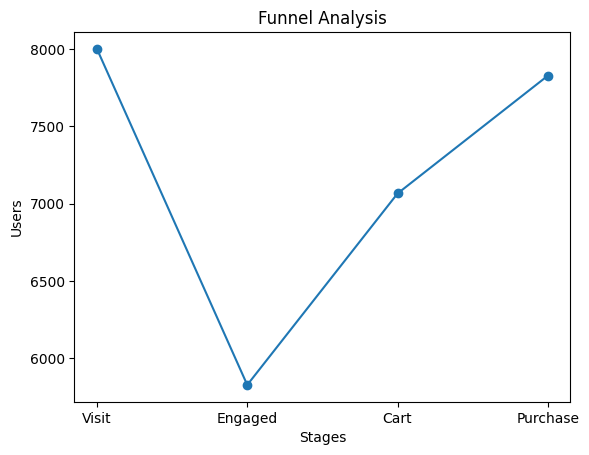

In [16]:
import matplotlib.pyplot as plt

stages = list(funnel.keys())
values = list(funnel.values())

plt.plot(stages, values, marker='o')
plt.title("Funnel Analysis")
plt.xlabel("Stages")
plt.ylabel("Users")
plt.show()